# **1. Perkenalan Dataset**


Dataset yang digunakan dalam eksperimen ini adalah **Telco Customer Churn Dataset** yang diperoleh dari Kaggle.

**Latar Belakang Bisnis:**
Customer churn merupakan permasalahan fundamental bagi industri telekomunikasi. Churn didefinisikan sebagai hilangnya pelanggan yang berpindah dari satu operator ke operator lain. Jika churn pelanggan dapat diprediksi lebih awal, perusahaan dapat mengambil tindakan preventif untuk mempertahankan pelanggan yang bernilai tinggi.

**Tujuan:**
Membangun model machine learning yang mampu memprediksi pelanggan yang akan berhenti berlangganan (churn) sehingga perusahaan dapat melakukan intervensi dini.

### **Variabel dalam Dataset:**

**X (Independent Variables / Fitur):**
| Kolom | Deskripsi |
|---|---|
| `customerID` | ID unik pelanggan (akan dihapus saat preprocessing) |
| `gender` | Jenis kelamin pelanggan (Male, Female) |
| `SeniorCitizen` | Apakah pelanggan lansia (1 = Ya, 0 = Tidak) |
| `Partner` | Apakah pelanggan memiliki pasangan (Yes, No) |
| `Dependents` | Apakah pelanggan memiliki tanggungan (Yes, No) |
| `tenure` | Jumlah bulan pelanggan telah berlangganan |
| `PhoneService` | Memiliki layanan telepon (Yes, No) |
| `MultipleLines` | Memiliki banyak saluran telepon |
| `InternetService` | Jenis layanan internet (DSL, Fiber optic, No) |
| `OnlineSecurity` | Layanan keamanan online |
| `OnlineBackup` | Layanan backup online |
| `DeviceProtection` | Layanan proteksi perangkat |
| `TechSupport` | Layanan dukungan teknis |
| `StreamingTV` | Layanan streaming TV |
| `StreamingMovies` | Layanan streaming film |
| `Contract` | Jenis kontrak (Month-to-month, One year, Two year) |
| `PaperlessBilling` | Tagihan paperless (Yes, No) |
| `PaymentMethod` | Metode pembayaran |
| `MonthlyCharges` | Biaya bulanan pelanggan |
| `TotalCharges` | Total biaya yang telah dibayarkan |

**Y (Dependent Variable / Target):**
| Kolom | Deskripsi |
|---|---|
| `Churn` | Apakah pelanggan churn (Yes = berhenti, No = bertahan) |

# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka Python yang dibutuhkan untuk manipulasi data, visualisasi, dan preprocessing.

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimpor.')

Semua library berhasil diimpor.


# **3. Memuat Dataset**

Memuat dataset Telco Customer Churn dari file CSV yang berada di folder raw.

In [50]:
dataset_path = "../Telco-Customer-Churn_Dataset_raw.csv"

df = pd.read_csv(dataset_path)

print(f"Dataset berhasil dimuat.")
print(f"Jumlah baris  : {df.shape[0]}")
print(f"Jumlah kolom  : {df.shape[1]}")

Dataset berhasil dimuat.
Jumlah baris  : 7043
Jumlah kolom  : 21


In [51]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita akan melakukan analisis mendalam terhadap dataset untuk memahami karakteristik data, distribusi nilai, korelasi antar fitur, dan mengidentifikasi anomali atau inkonsistensi data.

## 4.1 Informasi Umum Dataset

In [52]:
def check_data(dataframe, head=5):
    """
    Menampilkan ringkasan informasi dataset secara komprehensif,
    terstruktur, dan rapi untuk Jupyter Notebook maupun Terminal.
    """
    try:
        from IPython.display import display, HTML
        is_jupyter = True
    except ImportError:
        is_jupyter = False
    def print_header(title):
        """Membuat pembatas bagian yang rapi"""
        width = 70
        print("\n" + "=" * width)
        print(f" {title} ".center(width))
        print("=" * width)

    print_header("1. DIMENSI & DUPLIKASI DATA")
    print(f" • Jumlah Baris     : {dataframe.shape[0]:,}")
    print(f" • Jumlah Kolom     : {dataframe.shape[1]:,}")
    print(f" • Baris Duplikat   : {dataframe.duplicated().sum():,}")

    print_header("2. TIPE DATA & MISSING VALUES")
    missing_info = pd.DataFrame({
        'Tipe Data': dataframe.dtypes,
        'Missing Values': dataframe.isnull().sum(),
        'Persentase (%)': (dataframe.isnull().sum() / len(dataframe) * 100).round(2)
    })
    if is_jupyter:
        display(missing_info)
    else:
        print(missing_info.to_string())

    print_header(f"3. HEAD ({head} Baris Pertama)")
    if is_jupyter:
        display(dataframe.head(head))
    else:
        print(dataframe.head(head).to_string())

    print_header(f"4. TAIL ({head} Baris Terakhir)")
    if is_jupyter:
        display(dataframe.tail(head))
    else:
        print(dataframe.tail(head).to_string())

    print_header("5. STATISTIK DESKRIPTIF")
    stats = dataframe.describe(include='all').T.fillna('-')
    if is_jupyter:
        display(stats)
    else:
        print(stats.to_string())
        
    print("\n" + "=" * 70 + "\n")

check_data(df)


                     1. DIMENSI & DUPLIKASI DATA                      
 • Jumlah Baris     : 7,043
 • Jumlah Kolom     : 21
 • Baris Duplikat   : 0

                    2. TIPE DATA & MISSING VALUES                     


,Tipe Data,Missing Values,Persentase (%)
customerID,object,0,0.0
gender,object,0,0.0
SeniorCitizen,int64,0,0.0
Partner,object,0,0.0
Dependents,object,0,0.0
tenure,int64,0,0.0
PhoneService,object,0,0.0
MultipleLines,object,0,0.0
InternetService,object,0,0.0
OnlineSecurity,object,0,0.0



                      3. HEAD (5 Baris Pertama)                       


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



                      4. TAIL (5 Baris Terakhir)                      


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No



                       5. STATISTIK DESKRIPTIF                        


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043.0,7043,7590-VHVEG,1,-,-,-,-,-,-,-
gender,7043.0,2,Male,3555,-,-,-,-,-,-,-
SeniorCitizen,7043.0,-,-,-,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043.0,2,No,3641,-,-,-,-,-,-,-
Dependents,7043.0,2,No,4933,-,-,-,-,-,-,-
tenure,7043.0,-,-,-,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043.0,2,Yes,6361,-,-,-,-,-,-,-
MultipleLines,7043.0,3,No,3390,-,-,-,-,-,-,-
InternetService,7043.0,3,Fiber optic,3096,-,-,-,-,-,-,-
OnlineSecurity,7043.0,3,No,3498,-,-,-,-,-,-,-


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Observasi Awal:
- Kolom `TotalCharges` bertipe **object** padahal seharusnya numerik. Perlu dikonversi.
- Kolom `customerID` hanya berupa identifier unik dan tidak berguna untuk pemodelan.
- Target variabel adalah `Churn` dengan dua kelas (Yes/No).

## 4.2 Penanganan Tipe Data TotalCharges

In [54]:
print("Baris dengan TotalCharges yang tidak bisa dikonversi ke numerik:", end="")
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
print(f"{mask.sum()}\n")
print(df[mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

Baris dengan TotalCharges yang tidak bisa dikonversi ke numerik:11

      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


## 4.3 Konversi Target Variable

In [55]:
print("Distribusi target SEBELUM konversi:")
print(df['Churn'].value_counts())
print()

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("Distribusi target SETELAH konversi:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].mean()*100:.2f}%")

Distribusi target SEBELUM konversi:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Distribusi target SETELAH konversi:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Rate: 26.54%


## 4.4 Identifikasi Kolom Numerik dan Kategorik

In [56]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Mengidentifikasi nama kolom berdasarkan tipe:
    - cat_cols: Kolom kategorikal (termasuk numerik dengan jumlah unik < cat_th)
    - num_cols: Kolom numerik (non-kategorikal)
    - cat_but_car: Kolom kategorikal dengan kardinalitas tinggi (> car_th unik)
    """
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtype in ['object', 'category', 'bool']]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtype in ['int64', 'float64', 'int32', 'float32']]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtype in ['object', 'category']]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtype in ['int64', 'float64', 'int32', 'float32']]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations : {dataframe.shape[0]}")
    print(f"Variables    : {dataframe.shape[1]}")
    print(f"cat_cols     : {len(cat_cols)} -> {cat_cols}")
    print(f"num_cols     : {len(num_cols)} -> {num_cols}")
    print(f"cat_but_car  : {len(cat_but_car)} -> {cat_but_car}")
    print(f"num_but_cat  : {len(num_but_cat)} -> {num_but_cat}")

    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations : 7043
Variables    : 21
cat_cols     : 17 -> ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'Churn']
num_cols     : 3 -> ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_but_car  : 1 -> ['customerID']
num_but_cat  : 2 -> ['SeniorCitizen', 'Churn']


## 4.5 Visualisasi Distribusi Target (Churn)

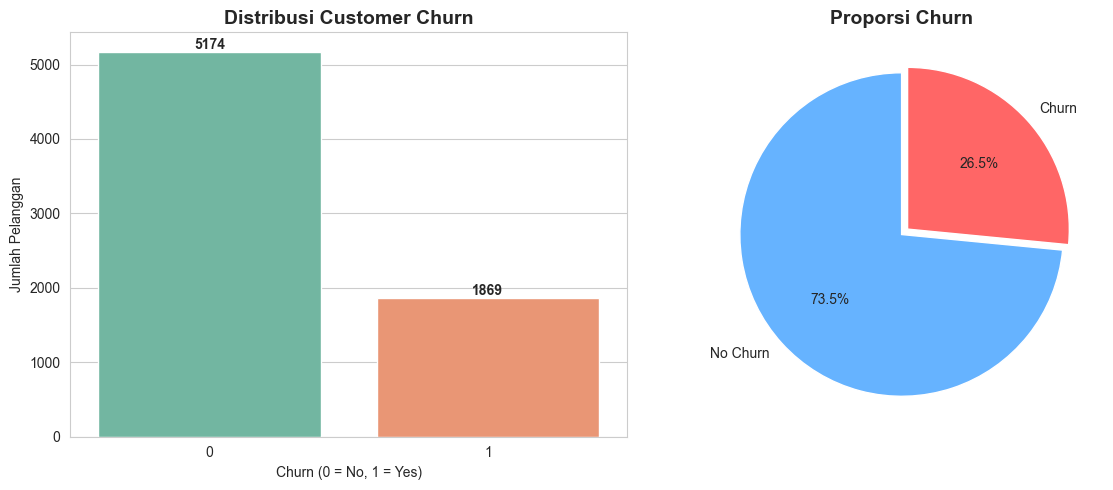

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
sns.countplot(x='Churn', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Customer Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0 = No, 1 = Yes)')
axes[0].set_ylabel('Jumlah Pelanggan')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[1].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#66b3ff', '#ff6666'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Proporsi Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4.6 Visualisasi Histogram Fitur Numerik

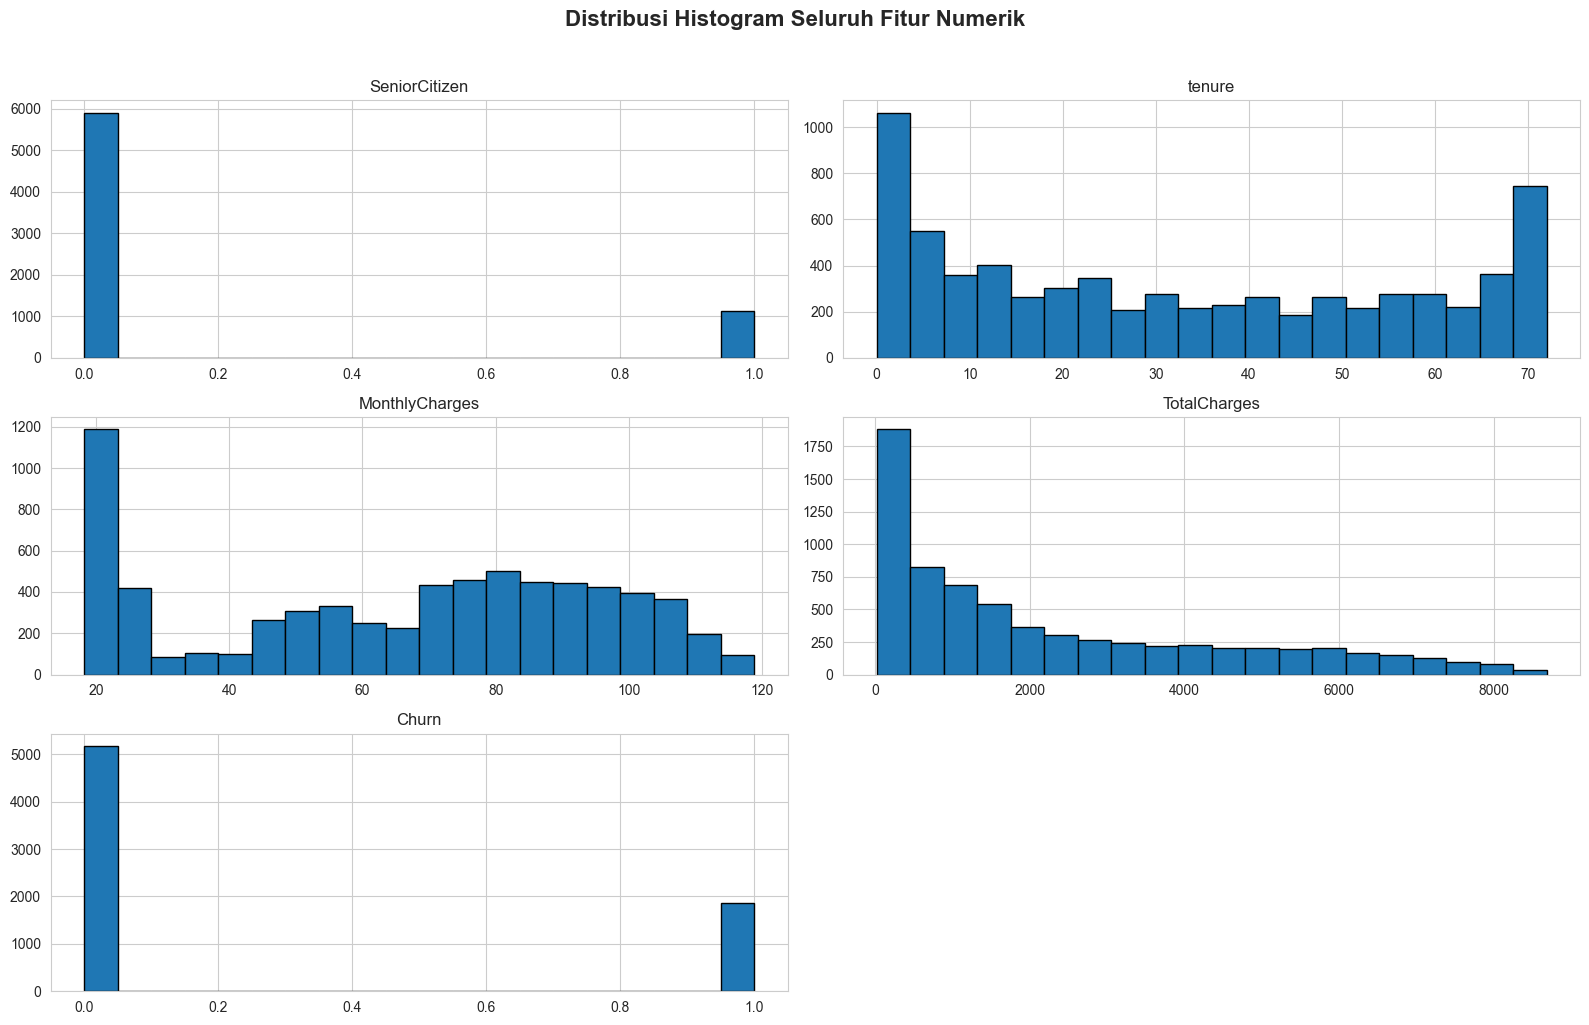

In [58]:
df.hist(bins=20, figsize=(16, 10), edgecolor='black')
plt.suptitle('Distribusi Histogram Seluruh Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.7 Analisis Target terhadap Variabel Kategorik

In [59]:
def target_summary_with_cat(dataframe, target, categorical_col):
    """Menampilkan rata-rata churn berdasarkan kategori."""
    print(pd.DataFrame({
        "CHURN_MEAN": dataframe.groupby(categorical_col)[target].mean(),
        "COUNT": dataframe.groupby(categorical_col)[target].count()
    }), end="\n\n")

cat_analysis_cols = [col for col in cat_cols if col != 'Churn']

for col in cat_analysis_cols:
    print(f"{'='*40}")
    print(f"TARGET vs {col}")
    print(f"{'='*40}")
    target_summary_with_cat(df, 'Churn', col)

TARGET vs gender
        CHURN_MEAN  COUNT
gender                   
Female    0.269209   3488
Male      0.261603   3555

TARGET vs Partner
         CHURN_MEAN  COUNT
Partner                   
No         0.329580   3641
Yes        0.196649   3402

TARGET vs Dependents
            CHURN_MEAN  COUNT
Dependents                   
No            0.312791   4933
Yes           0.154502   2110

TARGET vs PhoneService
              CHURN_MEAN  COUNT
PhoneService                   
No              0.249267    682
Yes             0.267096   6361

TARGET vs MultipleLines
                  CHURN_MEAN  COUNT
MultipleLines                      
No                  0.250442   3390
No phone service    0.249267    682
Yes                 0.286099   2971

TARGET vs InternetService
                 CHURN_MEAN  COUNT
InternetService                   
DSL                0.189591   2421
Fiber optic        0.418928   3096
No                 0.074050   1526

TARGET vs OnlineSecurity
                     CHUR

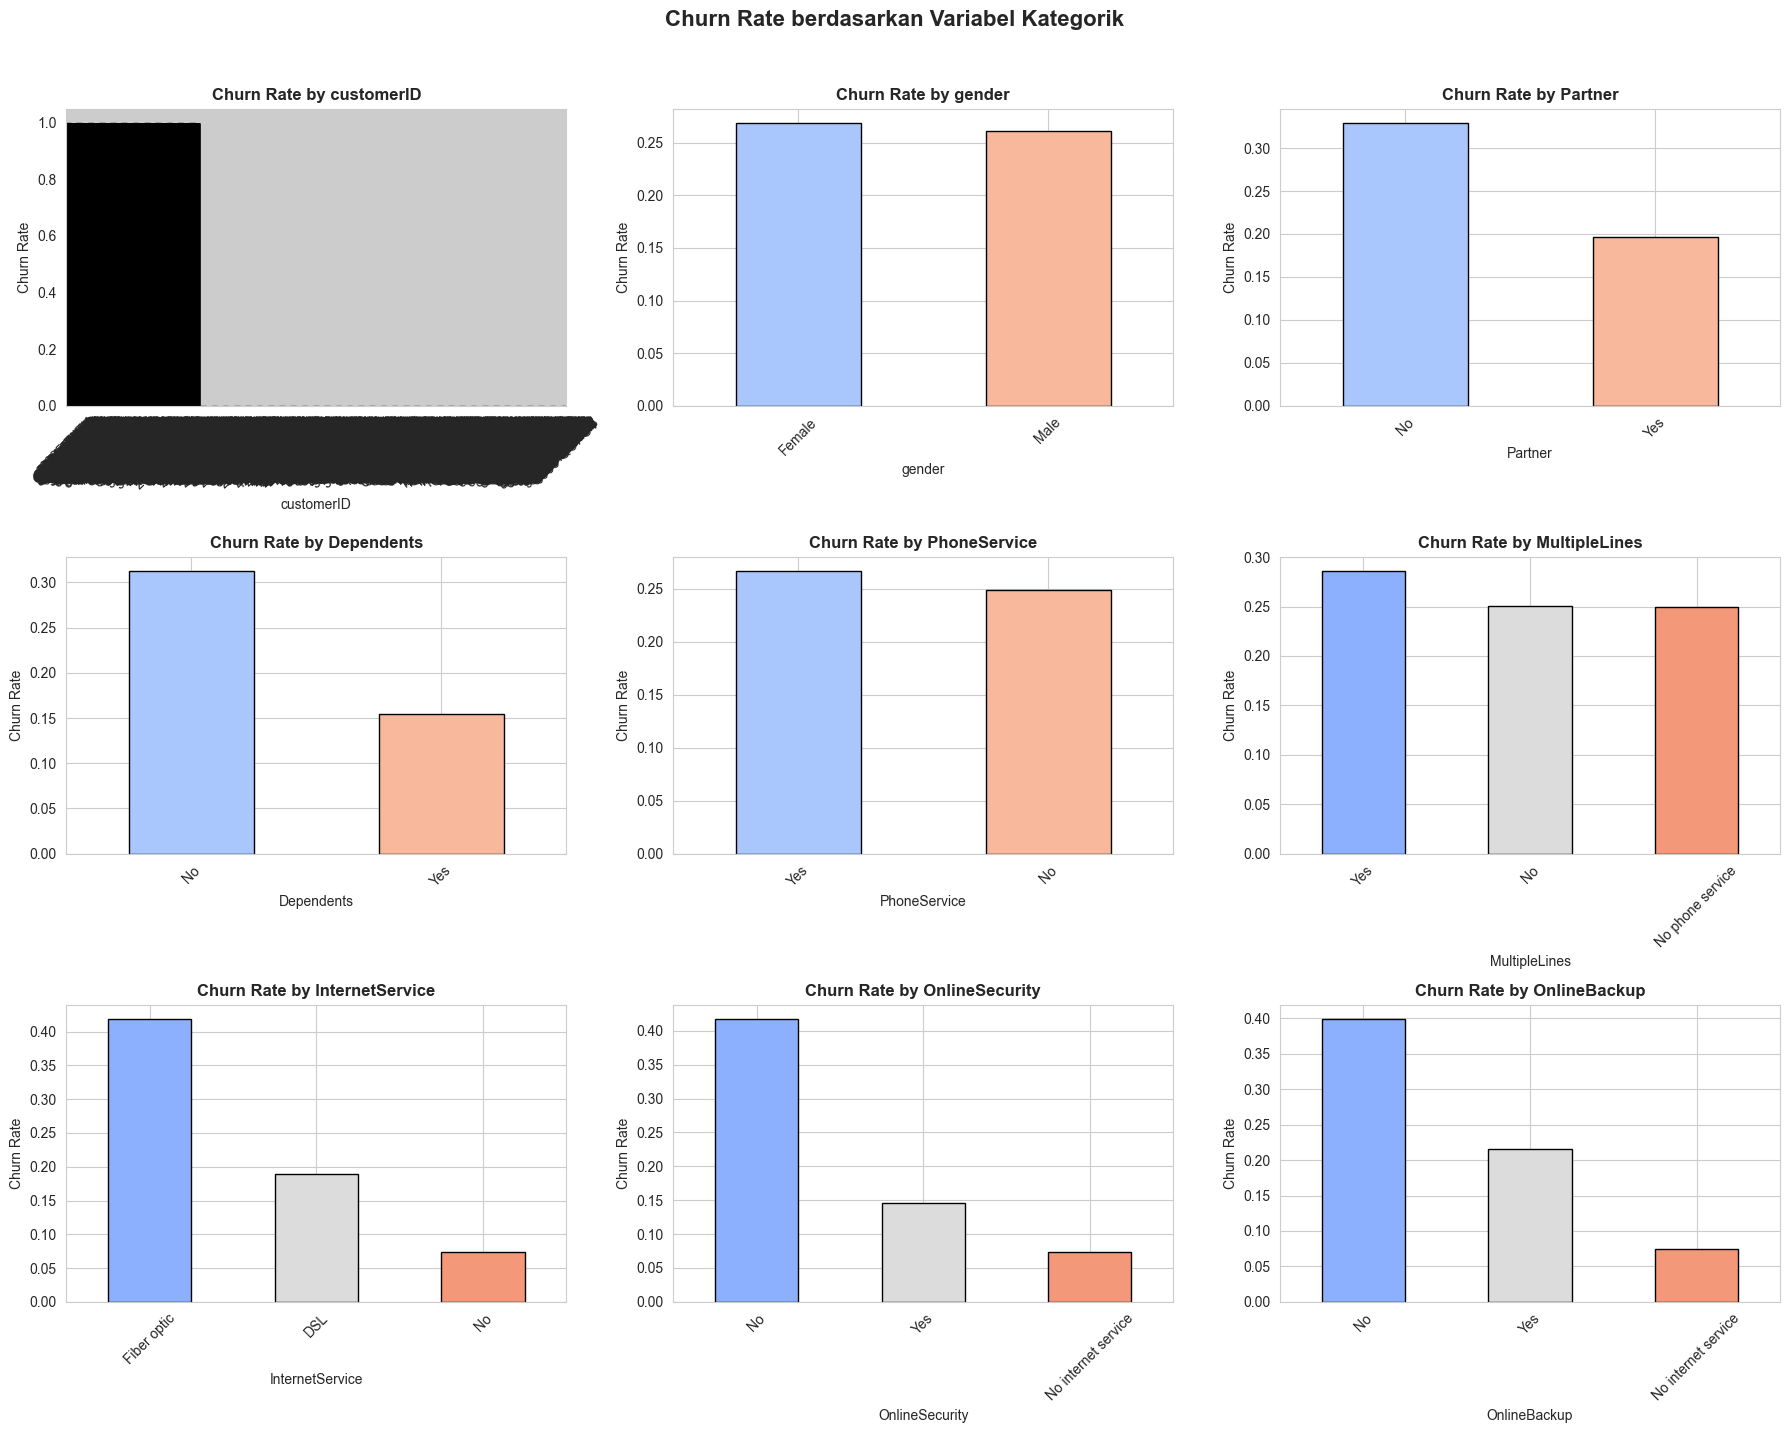

In [60]:
obj_cols = [col for col in df.columns if df[col].dtype == 'object']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(obj_cols[:9]):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color=sns.color_palette('coolwarm', len(churn_rate)), edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate berdasarkan Variabel Kategorik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Temuan Penting dari Analisis Kategorik:
- Tidak ada perbedaan signifikan antara churn pelanggan pria dan wanita.
- Churn rate pelanggan yang membayar dengan **Electronic Check** cenderung lebih tinggi.
- Pelanggan dengan kontrak **Month-to-month** memiliki churn rate tertinggi.
- Pelanggan yang menggunakan **Fiber Optic** memiliki churn rate lebih tinggi dibanding DSL.

## 4.8 Analisis Target terhadap Variabel Numerik

In [61]:
def target_summary_with_num(dataframe, target, numerical_col):
    """Menampilkan rata-rata fitur numerik berdasarkan target."""
    print(dataframe.groupby(target).agg({numerical_col: 'mean'}), end="\n\n")

for col in num_cols:
    print(f"{'='*40}")
    print(f"TARGET vs {col}")
    print(f"{'='*40}")
    target_summary_with_num(df, 'Churn', col)

TARGET vs tenure
          tenure
Churn           
0      37.569965
1      17.979133

TARGET vs MonthlyCharges
       MonthlyCharges
Churn                
0           61.265124
1           74.441332

TARGET vs TotalCharges
       TotalCharges
Churn              
0       2555.344141
1       1531.796094



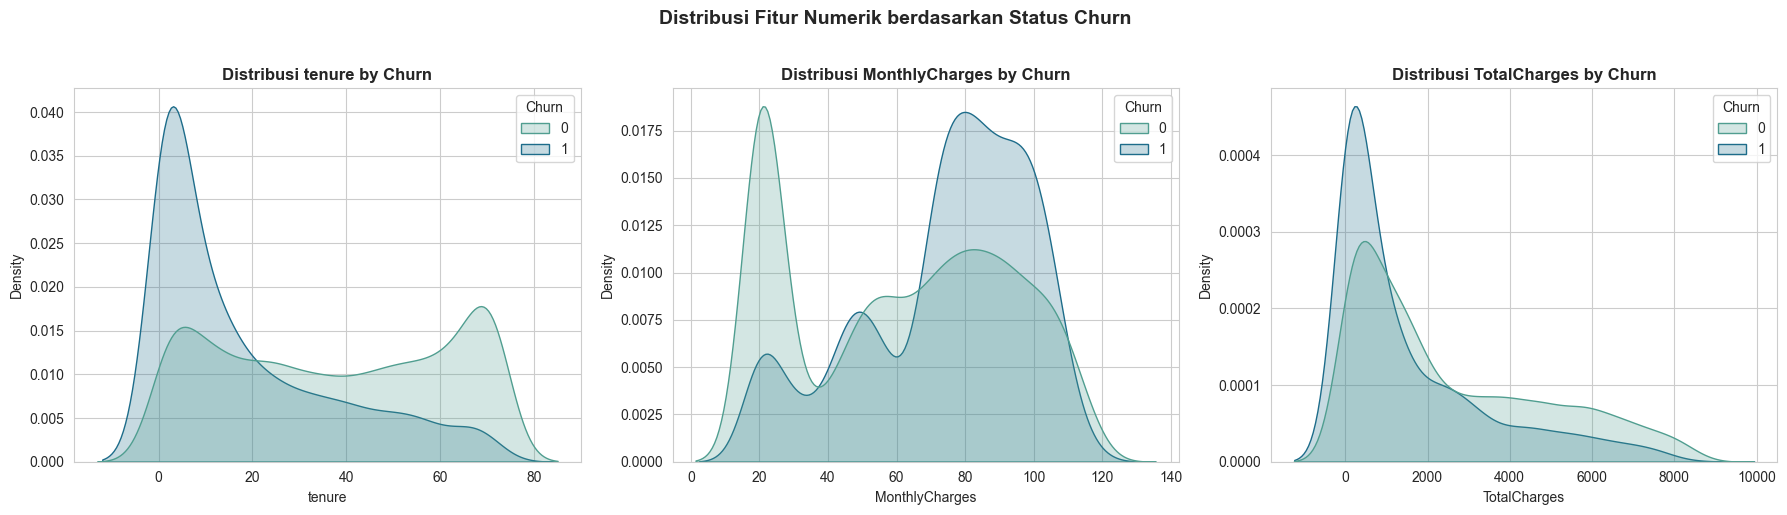

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False,
                palette='crest', ax=axes[i])
    axes[i].set_title(f'Distribusi {col} by Churn', fontweight='bold')

plt.suptitle('Distribusi Fitur Numerik berdasarkan Status Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.9 Analisis Outlier

In [63]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    """Menghitung batas bawah dan atas untuk deteksi outlier."""
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    iqr = quartile3 - quartile1
    low_limit = quartile1 - 1.5 * iqr
    up_limit = quartile3 + 1.5 * iqr
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    """Memeriksa apakah terdapat outlier pada kolom tertentu."""
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    outlier_count = ((dataframe[col_name] < low_limit) | (dataframe[col_name] > up_limit)).sum()
    return outlier_count > 0, outlier_count

print("Analisis Outlier".center(30))
for col in num_cols:
    has_outlier, count = check_outlier(df, col)
    status = f"ADA ({count} outlier)" if has_outlier else "TIDAK ADA"
    print(f"  {col:20s} -> Outlier: {status}")

       Analisis Outlier       
  tenure               -> Outlier: TIDAK ADA
  MonthlyCharges       -> Outlier: TIDAK ADA
  TotalCharges         -> Outlier: TIDAK ADA


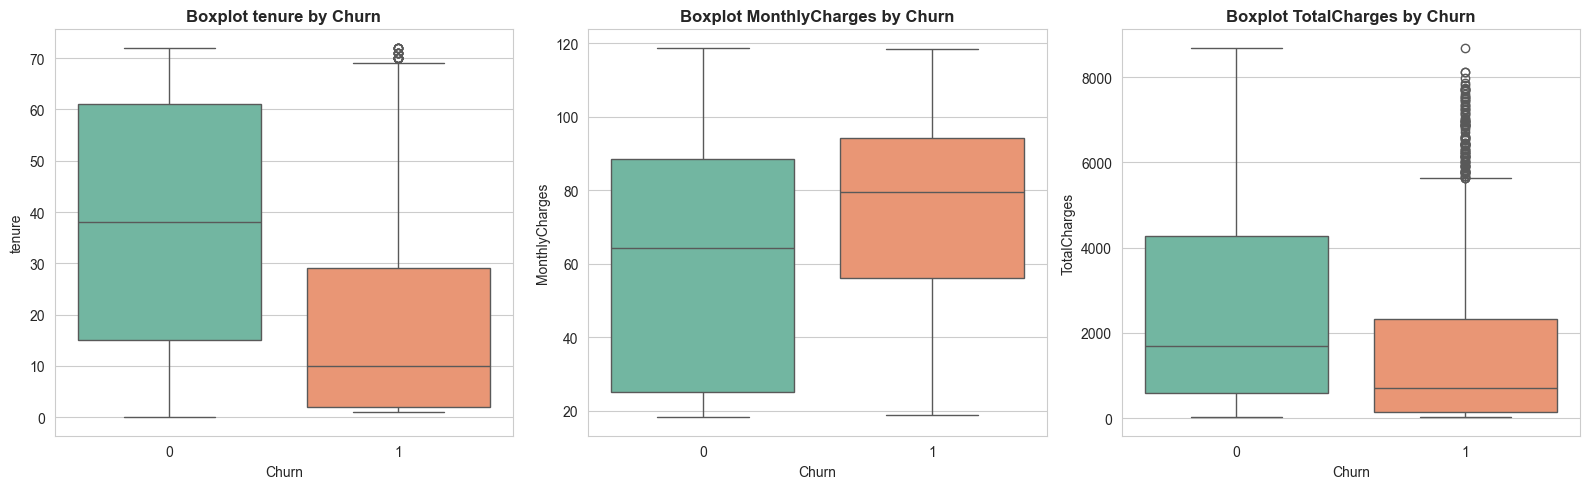

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(x='Churn', y=col, data=df, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Boxplot {col} by Churn', fontweight='bold')

plt.tight_layout()
plt.show()

## 4.10 Analisis Missing Values

In [65]:
def missing_values_table(dataframe, na_name=False):
    """Menampilkan tabel missing values beserta persentasenya."""
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]
    if len(na_columns) == 0:
        print("Tidak ada missing values dalam dataset.")
        return None

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns

na_cols = missing_values_table(df, True)

              n_miss  ratio
TotalCharges      11   0.16


## 4.11 Analisis Korelasi

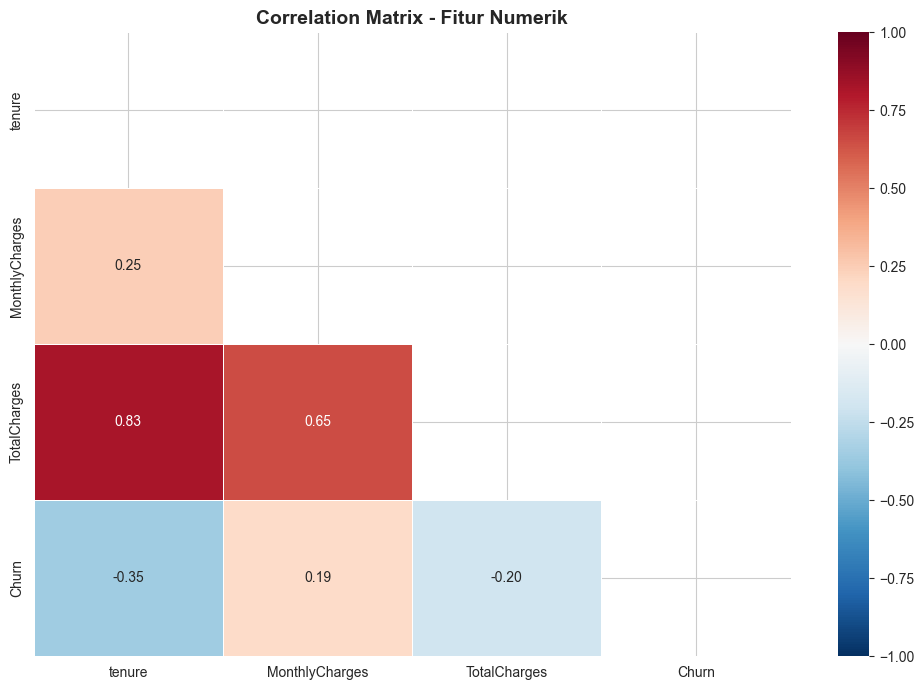

In [66]:
plt.figure(figsize=(10, 7))
numeric_df = df[num_cols + ['Churn']]
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix - Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [67]:
print("Korelasi terhadap Target (Churn)".center(50))
churn_corr = df.select_dtypes(include=[np.number]).corrwith(df['Churn']).sort_values(ascending=False)
print(churn_corr)

         Korelasi terhadap Target (Churn)         
Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
dtype: float64


### Temuan Korelasi:
- Terdapat **korelasi positif** antara `Churn` dan `SeniorCitizen` (pelanggan lansia cenderung churn).
- Terdapat **korelasi positif** antara `Churn` dan `MonthlyCharges` (semakin mahal biaya bulanan, semakin tinggi churn).
- Terdapat **korelasi negatif** antara `Churn` dan `tenure` (semakin lama berlangganan, semakin kecil kemungkinan churn).
- `TotalCharges` dan `tenure` memiliki korelasi positif tinggi (multikolinearitas ringan).

# **5. Data Preprocessing**

Tahapan preprocessing meliputi:
1. Menangani missing values
2. Menghapus kolom ID yang tidak relevan
3. Encoding kolom kategorikal binary (Label Encoding)
4. Encoding kolom kategorikal multi-class (One-Hot Encoding)
5. Standardisasi fitur numerik (StandardScaler)
6. Menyimpan dataset hasil preprocessing

## 5.1 Menangani Missing Values

In [68]:
# Mengisi missing values pada TotalCharges dengan median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Verifikasi missing values
print("Missing values setelah penanganan:")
print(df.isnull().sum().sum(), "-> Harus 0")

Missing values setelah penanganan:
0 -> Harus 0


## 5.2 Menghapus Kolom ID

In [69]:
df_clean = df.drop(columns=['customerID'])
print(f"Shape setelah drop customerID: {df_clean.shape}")

Shape setelah drop customerID: (7043, 20)


## 5.3 Encoding Kolom Kategorik Binary (Label Encoding)

In [70]:
le = LabelEncoder()

binary_cols = [col for col in df_clean.columns
               if df_clean[col].dtype == 'object' and df_clean[col].nunique() == 2]

print(f"Kolom binary yang akan di-label encode: {binary_cols}")

for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("Label encoding selesai.")

Kolom binary yang akan di-label encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Label encoding selesai.


## 5.4 Encoding Kolom Kategorik Multi-Class (One-Hot Encoding)

In [71]:
multiclass_cols = [col for col in df_clean.columns if df_clean[col].dtype == 'object']
print(f"Kolom multi-class yang akan di-OHE: {multiclass_cols}")

df_clean = pd.get_dummies(df_clean, columns=multiclass_cols, drop_first=True)

# Konversi kolom boolean hasil OHE ke integer 0/1
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print(f"Shape setelah OHE: {df_clean.shape}")
df_clean.head()

Kolom multi-class yang akan di-OHE: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Shape setelah OHE: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


## 5.5 Standardisasi Fitur Numerik

In [72]:
scaler = StandardScaler()
num_cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

df_clean[num_cols_to_scale] = scaler.fit_transform(df_clean[num_cols_to_scale])

print("Standardisasi selesai. Statistik setelah scaling:")
df_clean[num_cols_to_scale].describe().T

Standardisasi selesai. Statistik setelah scaling:


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,-2.421273e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
MonthlyCharges,7043.0,-6.406285e-17,1.000071,-1.545860,-0.972540,0.185733,0.833833,1.794352
TotalCharges,7043.0,-1.488074e-17,1.000071,-0.999120,-0.829846,-0.390463,0.664287,2.826743


## 5.6 Menyimpan Dataset Hasil Preprocessing

In [73]:
output_path = "..\Telco-Customer-Churn_Dataset_preprocessing.csv"
df_clean.to_csv(output_path, index=False)

print(f"Dataset preprocessed berhasil disimpan ke: {output_path}")
print(f"Shape akhir: {df_clean.shape}")
print(f"Kolom: {list(df_clean.columns)}")

Dataset preprocessed berhasil disimpan ke: ..\Telco-Customer-Churn_Dataset_preprocessing.csv
Shape akhir: (7043, 31)
Kolom: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [74]:
# Verifikasi akhir
print("=" * 50)
print("RINGKASAN PREPROCESSING")
print("=" * 50)
print(f"Shape awal   : {df.shape}")
print(f"Shape akhir  : {df_clean.shape}")
print(f"Missing val  : {df_clean.isnull().sum().sum()}")
print(f"Tipe data    :")
print(df_clean.dtypes.value_counts())

RINGKASAN PREPROCESSING
Shape awal   : (7043, 21)
Shape akhir  : (7043, 31)
Missing val  : 0
Tipe data    :
int64      28
float64     3
Name: count, dtype: int64
